In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az

In [2]:
data = get_data()
config, config_str = get_hmc_config()
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))

In [3]:
samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/samples_{config_str}.npy")
energy_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/energy_{config_str}.npy")
bias_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/bias_{config_str}.npy")
resampled_samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_unf_tb/resamp_{config_str}.npy")

In [4]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(4, 999900, 10)
(4, 1000000, 10)


In [5]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [6]:
print(energy_values)

[[158.77051293 111.36381485 123.84263049 ... 105.4331289  109.10459329
  146.58036862]
 [199.08770859 159.66171235 164.95756919 ...  78.3826745   81.17274688
   75.73210706]
 [167.80538575 105.49780318 130.32987547 ... 169.31890921 162.07841372
  148.73399685]
 [208.94105023 209.97907659 206.83360302 ... 116.25577436  95.77273769
  115.04799889]]


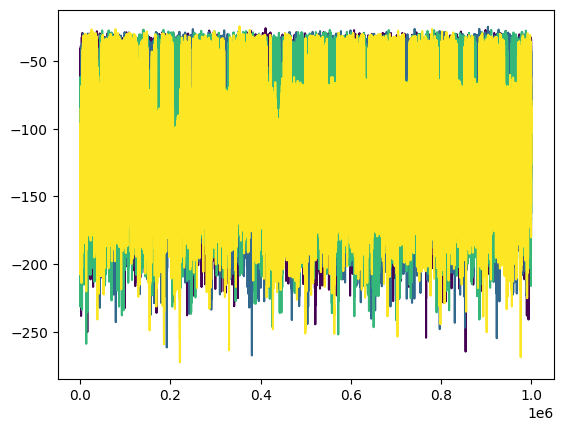

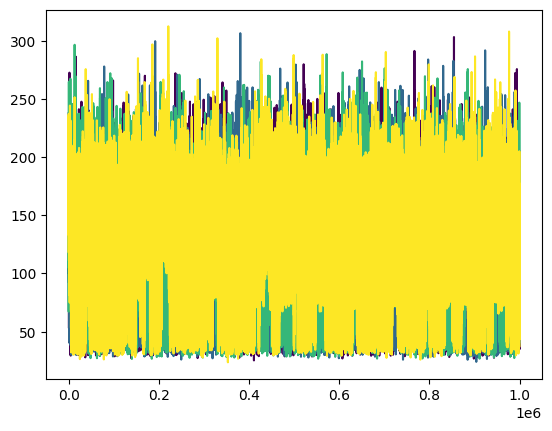

In [7]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.show()


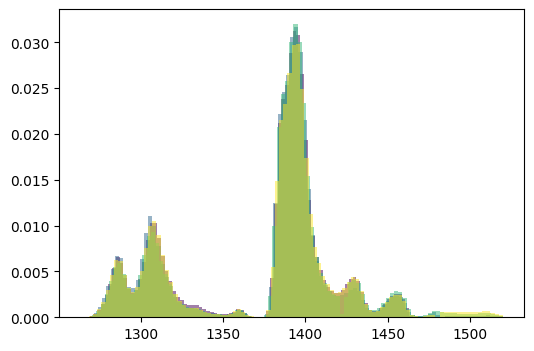

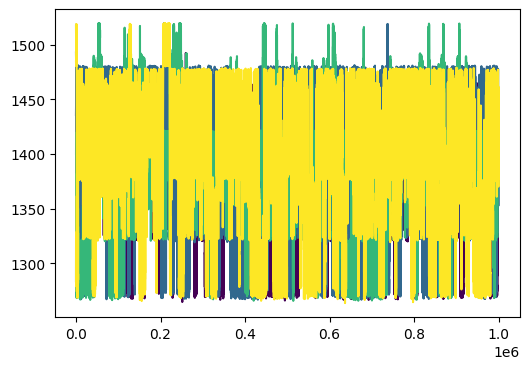

In [8]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

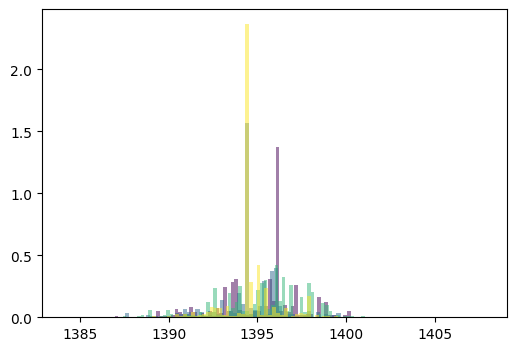

In [9]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :config["pidx"]], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [10]:
resampled_samples = resampled_samples[:,::1000,:]

In [11]:
print(np.max(bias_values))

-24.42703853745352


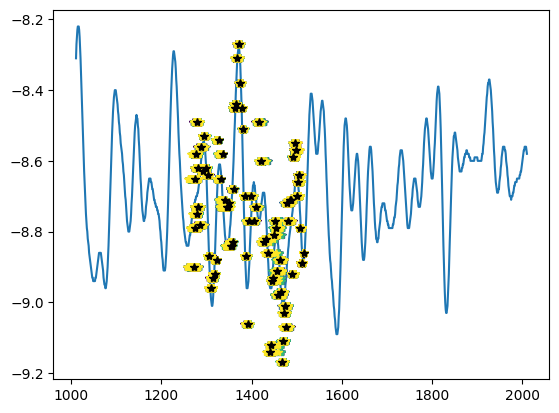

In [12]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [13]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

       mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]  10.36  0.97    8.28    11.92       0.08     0.01    101.01   3107.11   
x[1]  10.84  1.68    7.74    14.44       0.03     0.10   3535.19    396.53   
x[2]   8.32  2.16    3.72    12.42       0.11     0.04    264.29   3604.08   
x[3]  10.33  2.17    6.09    14.58       0.03     0.04   4240.88   3563.37   
x[4]  22.71  1.63   19.73    25.48       0.03     0.05    980.28    576.67   
x[5]  13.67  1.61   10.88    17.54       0.06     0.04    198.28   3475.22   
x[6]  13.30  1.96    9.61    17.21       0.03     0.03   3738.99   1997.90   
x[7]  14.62  2.05   10.35    18.11       0.04     0.03   2751.03   2934.32   
x[8]  14.71  1.93   11.71    18.76       0.28     0.03     47.11   3794.70   
x[9]   5.30  3.25    0.30    10.33       0.47     0.06     63.63   3646.98   

      r_hat  
x[0]   1.03  
x[1]   1.10  
x[2]   1.11  
x[3]   1.06  
x[4]   1.06  
x[5]   1.10  
x[6]   1.02  
x[7]   1.02  
x[8]   1.06  
x

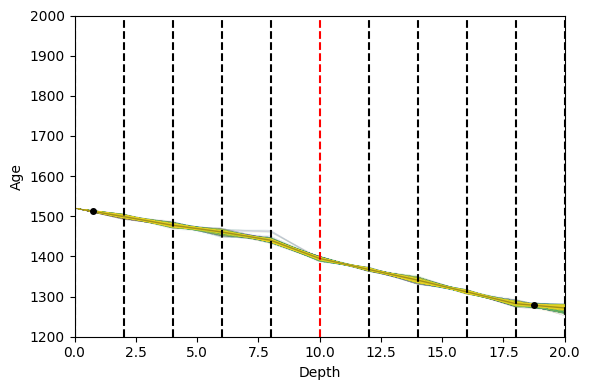

In [14]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
for i, c in enumerate(config["cs"]):
    if i != config["pidx"]:
        ax.axvline(x=c, color='k', linestyle='--')
    else:
        ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()